In [17]:
import pandas as pd
import numpy as np
import joblib
from pmdarima import ARIMA, auto_arima
from src.common.utils import get_root_directory, collate_array_elements, make_directory
from src.common.stats import adf_test, pp_test
import matplotlib.pyplot as plt
import numpy as np
from src.preprocessing.data_loader import DataLoader
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import mlflow

In [2]:
root_dir = get_root_directory()
DL = DataLoader(root_dir)
DL.load_data()
DL.set_time_range(start_date="01/01/2021", end_date="31/12/2023")
train, test = DL.split_data(split_size=0.15)
test = test["ETH_D_AvgPrc"]
train, val = DL.split_data(split_type="train_val",split_size=0.15)
train = train["ETH_D_AvgPrc"]
val = val["ETH_D_AvgPrc"]

In [3]:
adf_result = adf_test(train)
pp_result = pp_test(train)

In [4]:
print(f"Is time series based on ADF test is stationary: {adf_result.is_stationary}.")
print(f"Is time series based on PP test is stationary: {pp_result.is_stationary}.")

Is time series based on ADF test is stationary: False.
Is time series based on PP test is stationary: False.


In [5]:
 def make_stationary(df, alpha: float = 0.05, max_diffs: int = 5) -> None:
    """
    Iterates through each column in a DataFrame and differences it until it
    becomes stationary based on the Augmented Dickey-Fuller (ADF) test.

    Parameters:
        alpha: Significance level for the ADF test (default 0.05).
        max_diffs: Maximum number of differences to apply (default 5).

    Returns:
        None
    """
    diff_counts = {}

    for col in df.columns:
        series = df[col].dropna()
        diff_count = 0

        while diff_count < max_diffs:
            stationarity_result = adf_test(series)

            if stationarity_result.is_stationary:
                break
            series = series.diff().dropna()
            diff_count += 1

        df[col] = series
        diff_counts[col] = diff_count
        return df, diff_counts

In [6]:
train_diff, diff_counts = make_stationary(pd.DataFrame(train))

In [7]:
train_diff = train_diff.dropna()

In [8]:
adf_result = adf_test(train_diff)
pp_result = pp_test(train_diff)
print(f"Is time series based on ADF test is stationary: {adf_result.is_stationary}.")
print(f"Is time series based on PP test is stationary: {pp_result.is_stationary}.")
print(f"The value of d in Arima should be {diff_counts}")

Is time series based on ADF test is stationary: True.
Is time series based on PP test is stationary: True.
The value of d in Arima should be {'ETH_D_AvgPrc': 1}


In [9]:
train_log = np.log(train)

In [10]:
adf_result = adf_test(train_log)
pp_result = pp_test(train_log)
print(f"Is time series based on ADF test is stationary: {adf_result.is_stationary}.")
print(f"Is time series based on PP test is stationary: {pp_result.is_stationary}.")

Is time series based on ADF test is stationary: False.
Is time series based on PP test is stationary: False.


In [11]:
train_diff, diff_counts = make_stationary(pd.DataFrame(train_log))
train_diff = train_diff.dropna()
adf_result = adf_test(train_diff)
pp_result = pp_test(train_diff)
print(f"Is time series based on ADF test is stationary: {adf_result.is_stationary}.")
print(f"Is time series based on PP test is stationary: {pp_result.is_stationary}.")
print(f"The value of d in Arima should be {diff_counts}")

Is time series based on ADF test is stationary: True.
Is time series based on PP test is stationary: True.
The value of d in Arima should be {'ETH_D_AvgPrc': 1}


In [12]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

def plot_acf_pacf(series, lags=20):
    """
    Plot ACF and PACF graphs for a given time series.

    :param series: Pandas Series containing time series data.
    :param lags: Number of lags to display in the plots (default is 20).
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Plot ACF (for q selection in ARIMA)
    sm.graphics.tsa.plot_acf(series, lags=lags, ax=axes[0])
    axes[0].set_title("Autocorrelation Function (ACF)")

    # Plot PACF (for p selection in ARIMA)
    sm.graphics.tsa.plot_pacf(series, lags=lags, ax=axes[1])
    axes[1].set_title("Partial Autocorrelation Function (PACF)")

    plt.tight_layout()
    plt.show()

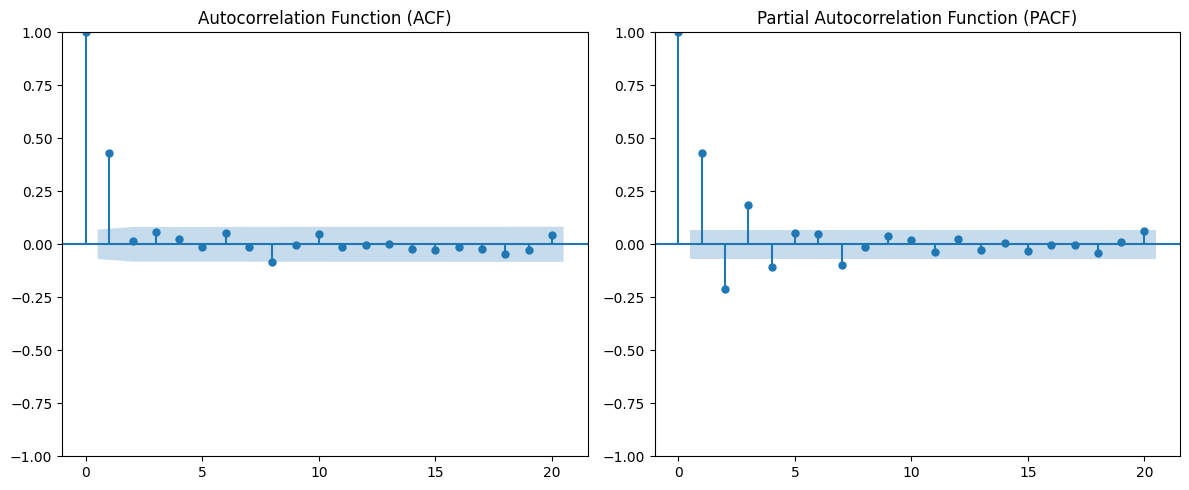

In [13]:
plot_acf_pacf(train_diff)

In [17]:
results = []
maxiter=500
n_periods=7
experiment_name = "ARIMA_train_validation"
mlflow.set_tracking_uri(f"sqlite:///{root_dir}/mlruns/mlruns.db")
mlflow.set_experiment(experiment_name)
log_transform = False

for p in range(1,7):
    for q in range(1,7):
        predictions = []
        if log_transform is True:
            val_gapped = np.log(val[:-n_periods])
            train_recursive = list(np.log(list(train)))
        else:
            val_gapped = val[:-n_periods]
            train_recursive = list(train)
        d =1
        order = (p, d, q)
        with mlflow.start_run(run_name=f"order_({p},{d},{q})"):
            model = ARIMA(maxiter=maxiter, order=order)
            mlflow.log_params({"log_transform":log_transform,"p": p,"d": d,"q": q,"maxiter":maxiter,"n_periods": n_periods})
            for t in range(len(val_gapped)):
                model.fit(train_recursive)
                forecast = model.predict(n_periods=n_periods)
                predictions.append(forecast)
                train_recursive.append(val_gapped.iloc[t])
            mse_list = []
            rmse_list = []
            mae_list = []
            mape_list = []
            transposed = collate_array_elements(predictions)
            if log_transform is True:
                transposed = np.exp(transposed)
            for i in range(len(transposed)):
                mse = mean_squared_error(val[i:-n_periods+i], transposed[i])
                rmse = root_mean_squared_error(val[i:-n_periods+i], transposed[i])
                mae = mean_absolute_error(val[i:-n_periods+i], transposed[i])
                mape = mean_absolute_percentage_error(val[i:-n_periods+i], transposed[i])
                mse_list.append(mse)
                rmse_list.append(rmse)
                mae_list.append(mae)
                mape_list.append(mape)
            avg_mse = sum(mse_list)/len(mse_list)
            avg_rmse = sum(rmse_list)/len(rmse_list)
            avg_mae = sum(mae_list)/len(mae_list)
            avg_mape = sum(mape_list)/len(mape_list)
            mlflow.log_metrics({"avg_mse": avg_mse, "avg_rmse": avg_rmse,"avg_mae": avg_mae,"avg_mape": avg_mape})
        mlflow.end_run()
        print(f"Completed order: {order}")

C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Completed order: (1, 1, 1)


C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Completed order: (1, 1, 2)


C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Completed order: (1, 1, 3)


C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

KeyboardInterrupt



In [19]:
experiment_name = "ARIMA_train_test"
mlflow.set_tracking_uri(f"sqlite:///{root_dir}/mlruns/mlruns.db")
mlflow.set_experiment(experiment_name)
log_transform = False
n_periods=7
maxiter=500
test_gapped = test[:-n_periods]
train_recursive = list(train)
train_recursive.extend(list(val))
predictions = []
if log_transform is True:
    test_gapped = np.log(test[:-n_periods])
    train_recursive = list(np.log(train_recursive))
order = (1, 1, 1)
p,d,q=order
model = ARIMA(maxiter=500, order=order)
mse_list = []
rmse_list = []
mae_list = []
mape_list = []
with mlflow.start_run(run_name=f"order_({p},{d},{q})"):
    mlflow.log_params({"log_transform":log_transform,"p": p,"d": d,"q": q,"maxiter":maxiter,"n_periods": n_periods})
    for t in range(len(test_gapped)):
        model.fit(train_recursive)
        forecast = model.predict(n_periods=n_periods)
        predictions.append(forecast.tolist())
        train_recursive.append(test_gapped.iloc[t])
    transposed = collate_array_elements(predictions)
    if log_transform is True:
        transposed = np.exp(transposed)
    for i in range(len(transposed)):
        mse = mean_squared_error(test[i:-n_periods+i], transposed[i])
        rmse = root_mean_squared_error(test[i:-n_periods+i], transposed[i])
        mae = mean_absolute_error(test[i:-n_periods+i], transposed[i])
        mape = mean_absolute_percentage_error(test[i:-n_periods+i], transposed[i])
        mse_list.append(mse)
        rmse_list.append(rmse)
        mae_list.append(mae)
        mape_list.append(mape)
        mlflow.log_metrics({"mse_daily":mse_list[i], "rmse_daily":rmse_list[i], "mae_daily":mae_list[i], "mape_daily":mape_list[i]}, step=(i+1))
    avg_mse = sum(mse_list)/len(mse_list)
    avg_rmse = sum(rmse_list)/len(rmse_list)
    avg_mae = sum(mae_list)/len(mae_list)
    avg_mape = sum(mape_list)/len(mape_list)
    mlflow.log_metrics({"avg_mse": avg_mse, "avg_rmse": avg_rmse,"avg_mae": avg_mae,"avg_mape": avg_mape})
    try:
        joblib.dump(model, f"{root_dir}\\mlruns\\ARIMA\\model.pkl")
        mlflow.log_artifact(f"{root_dir}\\mlruns\\ARIMA\\model.pkl")
    except Exception as e:
        make_directory(f"{root_dir}\\mlruns\\ARIMA")
        joblib.dump(model, f"{root_dir}\\mlruns\\ARIMA\\model.pkl")
        mlflow.log_artifact(f"{root_dir}\\mlruns\\ARIMA\\model.pkl")
    mlflow.end_run()

In [20]:
loaded_model = joblib.load(f"{root_dir}\\mlruns\\ARIMA\\model.pkl")

In [21]:
loaded_model.predict(7)

array([2310.63886319, 2312.09085339, 2313.53119284, 2314.97189051,
       2316.41257717, 2317.85326416, 2319.29395115])